In [1]:
# Décommenter la ligne suivante pour installer les dépendances
#%pip install jupyter_bokeh nbconvert panel watchfiles

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import panel as pn

pd.set_option('display.max_rows', 500)
import numpy as np

import requests
from bs4 import BeautifulSoup
import os
import s3fs
import ast
import json

pn.extension()

In [19]:
os.environ['AWS_S3_ENDPOINT']
S3_ENDPOINT_URL = 'http://' + os.environ['AWS_S3_ENDPOINT']
fs = s3fs.S3FileSystem(client_kwargs = {'endpoint_url' :S3_ENDPOINT_URL })
fs.ls('mlepennec-ensae')
BUCKET = 'mlepennec-ensae'
FILE_OUT_S3 = '/X_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    X_train = pd.read_csv(f_out)

In [20]:
FILE_OUT_S3 = '/y_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    y_train = pd.read_csv(f_out)

In [21]:
FILE_OUT_S3 = '/X_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    X_test = pd.read_csv(f_out)

In [22]:
FILE_OUT_S3 = '/y_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    y_test = pd.read_csv(f_out)

In [23]:
FILE_OUT_S3 = '/weights_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    weights_train = pd.read_csv(f_out)

In [25]:
FILE_OUT_S3 = '/weights_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    weights_test = pd.read_csv(f_out)

In [9]:
y_train

,vote_average
0,6.9
1,5.3
2,7.8
3,7.0
4,7.8
...,...
27562,6.6
27563,6.2
27564,6.5
27565,6.1


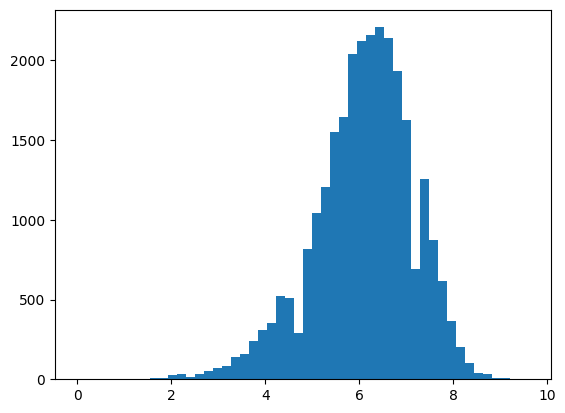

In [10]:
plt.hist(y_train['vote_average'], bins=50)
plt.show()

In [11]:
def get_y_hist(bins=30, density=True, histtype='bar', color='orange'):
    fig, ax = plt.subplots()
    ax.hist(y_train.vote_average, bins=bins, density=density, histtype=histtype, color=color)
    ax.set_xlabel("Moyenne des notes")
    ax.set_ylabel("Fréquence")
    plt.close(fig)
    return fig

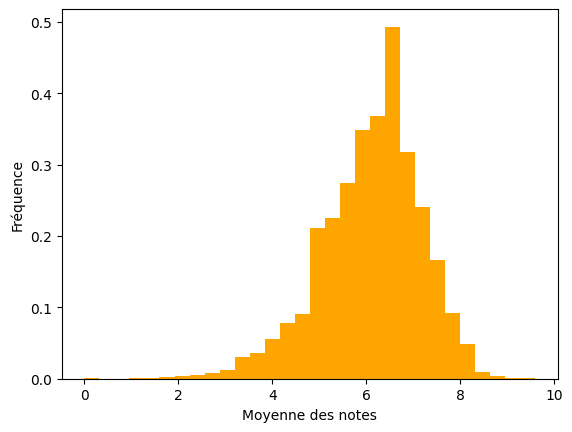

In [12]:
get_y_hist()

In [13]:
widget_bins = pn.widgets.IntSlider(name="Nombre de bins", start=1, end=100, value=50)


widget_density = pn.widgets.Checkbox(name="Densité")

widget_histtype = pn.widgets.Select(name='Histtype', options={'Barre' : 'bar', 'Contour' : 'step'})

widget_colorpicker = pn.widgets.ColorPicker(name='Color Picker', value='#ffa500')

In [14]:
faithful_hist = pn.bind(get_y_hist, bins=widget_bins, density=widget_density, histtype=widget_histtype, color=widget_colorpicker)


#pn.Column(widget_bins, pn.pane.Matplotlib(param_bins))

In [27]:

FILE_KEY_S3 = '/resultats.csv'
FILE_PATH_S3 = BUCKET+FILE_KEY_S3
with fs.open(FILE_PATH_S3, mode = "rb") as file_in : 
    resultats = pd.read_csv(file_in,sep=',', header=0)

FileNotFoundError: mlepennec-ensae/resultats.csv

In [ ]:


# ---- Contenu de chaque section ----
section_1 = pn.pane.Markdown("""
# 1. Introduction
Dans ce projet, nous avons décidé de nous intéresser à la base de données movies_metatadata.csv trouvable sur Kaggle, qui contient diverses informations sur 45 466 films sortis avant juillet 2017 (lien de la base kaggle). Cette base de données contient les variables suivantes :

- adult : indique si le film est "pour adultes"
- belongs to collection : si le film appartient à une saga de film, la variable renseigne les films faisant partie de cette saga
- budget : budget du film
- genres : genres du film
- homepage : lien vers le site officiel du film s'il y en a un
- id : identifiant du film dans la base de données
- imdb_id : identifiant IMDB du film
- original_language : langue originale du film
- original_title : titre original du film
- overview : résumé du film
- popularity : popularité du film sur IMDB
- poster_path : lien vers l'affiche du film
- production_countries : pays de production du film
- production_companies : compagnies de production du film
- release_date : date de sortie du film
- revenue : recettes du film
- runtime : durée du film
- spoken_languages : langues parlées dans le film en version originale
- status : si le film est sorti, prévu, annulé, en production etc
- tagline : catchphrase du film
- title : titre anglophone du film
- video : False si le film est sorti au cinéma, True s'il est sorti directement sur Internet et qu'il n'a pas été diffusé au cinéma

Nous complétons ces informations avec la base de données credits.csv trouvble au même endroit et qui contient :
- id : identifiant du film dans la base de données
- cast : casting du film 
- crew : équipe du film 

Nous souhaitons à partir de ces données prédire la note de nouveaux films, voir quelles sont les variables les plus décisives pour prédire si un film sera bien reçu par le public et ainsi remarquer (ou non) la prévisibilité du succès d'un film.
""")



section_2 = pn.pane.Markdown("""
# 2. Retraitements
Après première exploration des données movies_metadata, nous décidons d'enlever les variables suivantes : 

- adult : elle présente presque toujours la modalité False
- homepage : renseigne le lien vers le site officiel du film s'il y en a un
- overview : contient les résumés des films, ce qui peut être intéressant à exploiter mais nous avons décidé de ne pas le faire
- popularity : popularité du film sur IMDB au moment où les données ont été extraites, c'est donc une variable qui n'est pas statique et qui est calculée directement par IMDB d'une façon que nous ignorons donc nous ne souhaitons pas la prendre en compte
- poster_path : lien vers l'affiche du film
- spoken_languages : indique les langues parlées durant le film en version originale, nous considérons que cette variable est redondante par rapport à la variable original_language
- tagline indique la catchphrase du film

Nous allons nous concentrer sur les films qui sont déjà sortis en salle (status = Released et video=False) et qui ont un nombre de vote sur IMDB supérieur strictement à 0. Nous n'allons pas prendre en compte la variable revenue dans cette étude car nous souhaitons être capables de prédire la note d'un nouveau film dont on ne connaît pas encore les recettes.
Nous enlevons aussi les films où la date de sortie ou l'identifiant IMDB sont manquants (cela représente une soixantaine de films).

Une fois les variables nommées ci-dessus enlevées et les filtres appliqués, la base de données movies_metadata contient 42 028 films et 14 variables.

## Retraitement de la variable belongs_to_collection

La variable belongs_to_collection est vide si le film ne fait pas partie d'une saga et contient la liste des films de la saga si le film en question fait partie d'une saga de films, sous forme de liste de dictionnaires. Ce format fait qu'un retraitement est obligatoire. Nous créons une variable indic_collec qui vaut 1 si le film fait partie d'une saga et 0 sinon, puis une variable rang qui indique le numéro du film dans la saga et une variable vote_prec qui contient la note du film précédent dans la saga.

## Retraitement de la variable genres

La variable genres, qui indique les différents genres du film, est elle aussi sous forme de liste de dictionnaires. Chaque film peut avoir entre 0 et 8 genres différents parmi 20 genres possibles.

## Retraitement de la variable production_countries

## Retraitement de la variable budget

## Retraitement des variables cast et crew

## Retraitement de la variable production_companies

""")

section_3 = pn.pane.Markdown("""
# 3. Statistiques descriptives
Encore un autre contenu.
""")

section_4 = pn.pane.Markdown("""
# 4. Machine Learning

## Modèles de régression

## Random Forest

Comme nous l'avons vu précédemment, le RMSE est plûtot bon, cependant le R² reste relativement faible. 
Etant donné que la distribution de la variable cible correspond à celle d'une loi normale, on peut supposer que le modèle prédit en moyenne correctement (bon RMSE) mais ne capte pas bien la variance des données (notes extrêmes).
Dans l'optimisation des hyperparamètres du modèle, nous allons donc chercher à maximiser le R² et regarder si cela améliore ou détériore le RMSE.

Les hyperparamètres que nous avons optimisés sont les suivants : 
- n_estimators : de 100 à 1000
- max_depth : de None à 100
- min_samples_split : de 2 à 10
- min_samples_leaf : de 1 à 4
- max_features : sqrt ou log2

L'optimisation des hyperparamètres s'est faite par cross validation sur 5 folds.

Le modèle Random Forest optimal est celui avec n_estimators=1000, max_depth = 50, min_samples_split=2, min_samples_leaf=2 et max_features=sqrt.
Ci-dessous le tableau des métriques classiques et pondérées pour le Random Forest :

Nous pouvons observer que toutes les métriques sont meilleures que celles de la régression linéaire. 
Les RMSE et MAE (classiques et pondérés) ont augmenté avec le R², ce qui indique que le modèle a réussi à mieux capturer la variance des données et à prédire plus finement les notes.
Les métriques pondérées sont toujours plus faibles que les métriques classiques, ce qui signifie que le modèle est meilleur sur les films avec le plus de votes, donc plus populaires.

## Gradient Boosting

Dans l'optimisation des hyperparamètres du modèle, nous allons chercher à maximiser le R² avec la même logique que pour le Random Forest.

Les hyperparamètres que nous avons optimisés sont les suivants : 
- n_estimators : de 100 à 1000
- learning rate : de 0.01 à 0.1
- max_depth : de 3 à 10
- min_samples_leaf : de 1 à 4
- subsample : de 0.8 à 1

L'optimisation des hyperparamètres s'est faite par cross validation sur 5 folds.

Le modèle Gradient Boosting optimal est celui avec n_estimators=1000, learning_rate=0.01, max_depth = 10, min_samples_leaf=3 et subsample=0.8.
Ci-dessous le tableau des métriques classiques et pondérées pour le Gradient Boosting :

## Réseaux de neurones
""")

section_5 = pn.pane.Markdown("""
# 5. Conclusion
Encore un autre contenu.
""")

# ---- Zone centrale qui change ----
main_area = pn.Column(section_1)

# ---- Fonctions de navigation ----
def show_section_1(event):
    main_area.objects = [section_1]

def show_section_2(event):
    main_area.objects = [section_2]

def show_section_3(event):
    main_area.objects = [section_3, get_y_hist()]

def show_section_4(event):
    main_area.objects = [section_4]

def show_section_5(event):
    main_area.objects = [section_5]

# ---- Sidebar = menu latéral ----
sidebar = pn.Column(
    pn.pane.Markdown("## Menu"),
    pn.widgets.Button(name="1. Introduction"),
    pn.widgets.Button(name="2. Retraitements"),
    pn.widgets.Button(name="3. Statistiques descriptives"),
    pn.widgets.Button(name="4. Machine Learning"),
    pn.widgets.Button(name="5. Conclusion"),
)

# Association des boutons aux fonctions
sidebar[1].on_click(show_section_1)
sidebar[2].on_click(show_section_2)
sidebar[3].on_click(show_section_3)
sidebar[4].on_click(show_section_4)
sidebar[5].on_click(show_section_5)

# ---- Template global ----
template = pn.template.BootstrapTemplate(title="Projet Datascience - Cécile Prévot et Marie Le Pennec")

template.sidebar.append(sidebar)
template.main.append(main_area)

template.servable()


BootstrapTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] BootstrapTemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [nav-140299631558032] Column
        [0] Markdown(str)
        [1] Button(name='1. Introduction')
        [2] Button(name='2. Retraitements')
        [3] Button(name='3. Statistiques d...)
        [4] Button(name='4. Machine Learning')
        [5] Button(name='5. Conclusion')
    [main-140299645590496] Column
        [0] Markdown(str)

In [16]:
#panel serve --autoreload --show --allow-websocket-origin=$(echo $VSCODE_PROXY_URI | cut -d '/' -f 3) /home/onyxia/work/formation_cepe/Projet/panel_projet.ipynb